# First Classification attempt - Remove some features

I'm going to use machine learning models to predict the injury status of the players with the data we have.
I do not expect to get good results, but I want to get a baseline to compare after improving the data and trying more advance techniques and models.

I'm going to use the following models:
- Logistic Regression
- Random Forest
- XGBoost
- Support Vector Machines

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb


import joblib
import os

import core.constants as c
from core.utils import extract_subject_id
from core.model_selection import (
    train_model_with_cv_eval,
    evaluate_models,
    save_models_and_results,
    load_models_and_results,
    plot_comparison_and_confusion,
    split_train_test_set
)


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [11]:
SAVE_MODEL = True
SAVE_DATA = True
MODEL_NAME = "clasical_ml_model_selection_v4_missing_data"

In [12]:
X = pd.read_csv(c.RICKD_BASELINE_X_FILE_V2, index_col=0)
Y = pd.read_csv(c.RICKD_BASELINE_Y_FILE_V2, index_col=0)

print(f"X Dataset shape: {X.shape}")
print(f"X Columns: {list(X.columns)}")
display(X.head())

print(f"Y Dataset shape: {Y.shape}")
print(f"Y Columns: {list(Y.columns)}")
display(Y.head())

# Class imbalance
print(f"Class distribution: {Y['is_injured'].value_counts()}")
print(f"Class distribution: {Y['is_injured'].value_counts(normalize=True)}")

X Dataset shape: (1832, 93)
X Columns: ['speed_r', 'age', 'Height', 'Weight', 'YrsRunning', 'NumRaces', 'l_step_width', 'l_stride_rate', 'l_stride_length', 'l_swing_time', 'l_stance_time', 'l_pelvis_peak_drop_angle', 'l_pelvis_drop_excursion', 'l_ankle_df_peak_angle', 'l_ankle_eve_peak_angle', 'l_ankle_eve_percent_stance', 'l_ankle_eve_excursion', 'l_ankle_rot_peak_angle', 'l_ankle_rot_excursion', 'l_knee_flex_peak_angle', 'l_knee_add_peak_angle', 'l_knee_add_excursion', 'l_knee_abd_peak_angle', 'l_knee_abd_excursion', 'l_knee_rot_peak_angle', 'l_knee_rot_excursion', 'l_hip_ext_peak_angle', 'l_hip_add_peak_angle', 'l_hip_add_excursion', 'l_hip_rot_peak_angle', 'l_hip_rot_excursion', 'l_foot_prog_angle', 'l_foot_ang_at_hs', 'l_mhw_exc_from_to', 'l_ankle_eve_peak_vel', 'l_ankle_rot_peak_vel', 'l_knee_abd_peak_vel', 'l_knee_add_peak_vel', 'l_hip_abd_peak_vel', 'l_knee_rot_peak_vel', 'l_hip_rot_peak_vel', 'l_pronation_onset', 'l_pronation_offset', 'l_peak_hip_add_velocity', 'l_peak_pelvic_

,speed_r,age,Height,Weight,YrsRunning,NumRaces,l_step_width,l_stride_rate,l_stride_length,l_swing_time,...,r_peak_hip_add_velocity,r_peak_pelvic_drop_velocity,r_vertical_oscillation,Gender_female,Gender_male,DominantLeg_ambidextrous,DominantLeg_left,DominantLeg_right,Level_competitive,Level_recreational
id,,,,,,,,,,,,,,,,,,,,,
100433_20101005T132240,-2.406926,1.232956,0.045388,-0.087876,0.370320,-0.124719,-0.307243,0.000986,-2.622528,-0.338913,...,-1.743700,0.239058,-2.149309,0.0,0.0,0.0,0.0,0.0,0.0,1.0
100434_20101117T132240,-1.095016,1.068010,0.045388,-0.087876,1.214620,-0.124719,-1.831460,0.886585,-1.458975,-0.466027,...,0.764244,-0.390267,-1.504414,1.0,0.0,0.0,0.0,0.0,0.0,1.0
100537_20120703T102550,-1.325076,-0.086615,0.072581,-0.200098,-0.956438,-0.124719,-0.037324,-0.643565,-1.241474,-0.084685,...,2.255015,0.604189,-0.347673,1.0,0.0,0.0,0.0,1.0,0.0,1.0
100560_20120717T103748,-0.215279,-0.416508,0.746976,0.952054,-0.232752,-0.124719,0.677045,-1.610390,0.439240,-1.165155,...,3.526927,-1.746297,1.432837,1.0,0.0,0.0,0.0,1.0,0.0,1.0
101481_20120717T105021,-0.282875,-0.498981,0.420656,-0.873434,-0.232752,-0.124719,0.104643,-0.746010,-0.016982,-0.148242,...,0.475554,1.000454,0.680932,1.0,0.0,0.0,0.0,0.0,0.0,0.0


Y Dataset shape: (1832, 13)
Y Columns: ['injury_severity_code', 'injury_severity_value', 'injury_code', 'injury2_code', 'injury_desc', 'injury2_desc', 'injury_name', 'injury2_name', 'injured_joint_code', 'injured_joint2_code', 'injured_side_code', 'injured_side2_code', 'is_injured']


,injury_severity_code,injury_severity_value,injury_code,injury2_code,injury_desc,injury2_desc,injury_name,injury2_name,injured_joint_code,injured_joint2_code,injured_side_code,injured_side2_code,is_injured
id,,,,,,,,,,,,,
100433_20101005T132240,volume_intensity,2.0,pain,no_injury,General sensation of discomfort without speci...,No injury has been diagnosed.,pain,no injury,knee,no_injury,right,right,1
100434_20101117T132240,volume_intensity,2.0,disc_dege,no_injury,Breakdown and gradual loss of spinal disc cush...,No injury has been diagnosed.,disc degeneration,no injury,lumbar_spine,no_injury,bilateral,right,1
100537_20120703T102550,missed_2_workouts,3.0,pain,no_injury,General sensation of discomfort without speci...,No injury has been diagnosed.,pain,no injury,hip_pelvis,no_injury,right,right,1
100560_20120717T103748,no_injury,0.0,no_injury,no_injury,No injury has been diagnosed.,No injury has been diagnosed.,no injury,no injury,no_injury,no_injury,right,right,0
101481_20120717T105021,no_injury,0.0,no_injury,no_injury,No injury has been diagnosed.,No injury has been diagnosed.,no injury,no injury,no_injury,no_injury,no_injury,no_injury,0


Class distribution: is_injured
1    1167
0     665
Name: count, dtype: int64
Class distribution: is_injured
1    0.637009
0    0.362991
Name: proportion, dtype: float64


In [13]:
selected_cols = [
    # "speed_r",
    "age",
    "Height",
    "Weight",
    #"YrsRunning",
    #"NumRaces",
    "l_step_width",
    "l_stride_rate",
    "l_stride_length",
    "l_swing_time",
    "l_stance_time",
    "l_pelvis_peak_drop_angle",
    "l_pelvis_drop_excursion",
    "l_ankle_df_peak_angle",
    "l_ankle_eve_peak_angle",
    "l_ankle_eve_percent_stance",
    "l_ankle_eve_excursion",
    "l_ankle_rot_peak_angle",
    "l_ankle_rot_excursion",
    "l_knee_flex_peak_angle",
    "l_knee_add_peak_angle",
    "l_knee_add_excursion",
    "l_knee_abd_peak_angle",
    "l_knee_abd_excursion",
    "l_knee_rot_peak_angle",
    "l_knee_rot_excursion",
    "l_hip_ext_peak_angle",
    "l_hip_add_peak_angle",
    "l_hip_add_excursion",
    "l_hip_rot_peak_angle",
    "l_hip_rot_excursion",
    "l_foot_prog_angle",
    "l_foot_ang_at_hs",
    "l_mhw_exc_from_to",
    "l_ankle_eve_peak_vel",
    "l_ankle_rot_peak_vel",
    "l_knee_abd_peak_vel",
    "l_knee_add_peak_vel",
    "l_hip_abd_peak_vel",
    "l_knee_rot_peak_vel",
    "l_hip_rot_peak_vel",
    "l_pronation_onset",
    "l_pronation_offset",
    "l_peak_hip_add_velocity",
    "l_peak_pelvic_drop_velocity",
    "l_vertical_oscillation",
    "r_step_width",
    "r_stride_rate",
    "r_stride_length",
    "r_swing_time",
    "r_stance_time",
    "r_pelvis_peak_drop_angle",
    "r_pelvis_drop_excursion",
    "r_ankle_df_peak_angle",
    "r_ankle_eve_peak_angle",
    "r_ankle_eve_percent_stance",
    "r_ankle_eve_excursion",
    "r_ankle_rot_peak_angle",
    "r_ankle_rot_excursion",
    "r_knee_flex_peak_angle",
    "r_knee_add_peak_angle",
    "r_knee_add_excursion",
    "r_knee_abd_peak_angle",
    "r_knee_abd_excursion",
    "r_knee_rot_peak_angle",
    "r_knee_rot_excursion",
    "r_hip_ext_peak_angle",
    "r_hip_add_peak_angle",
    "r_hip_add_excursion",
    "r_hip_rot_peak_angle",
    "r_hip_rot_excursion",
    "r_foot_prog_angle",
    "r_foot_ang_at_hs",
    "r_mhw_exc_from_to",
    "r_ankle_eve_peak_vel",
    "r_ankle_rot_peak_vel",
    "r_knee_abd_peak_vel",
    "r_knee_add_peak_vel",
    "r_hip_abd_peak_vel",
    "r_knee_rot_peak_vel",
    "r_hip_rot_peak_vel",
    "r_pronation_onset",
    "r_pronation_offset",
    "r_peak_hip_add_velocity",
    "r_peak_pelvic_drop_velocity",
    "r_vertical_oscillation",
    # "Gender_female",
    # "Gender_male",
    # "DominantLeg_ambidextrous",
    # "DominantLeg_left",
    # "DominantLeg_right",
    # "Level_competitive",
    # "Level_recreational",
]
X_filtered = X[selected_cols]

In [15]:
from core.utils import extract_subject_id

y = Y["is_injured"]
X_train, X_test, y_train, y_test = split_train_test_set(
    X_filtered, y, test_size=0.2, random_state=RANDOM_STATE, groups=extract_subject_id(X.index.to_series())
)

X_train, X_val, y_train, y_val = split_train_test_set(
    X_train, y_train, test_size=0.2, random_state=RANDOM_STATE, groups=extract_subject_id(X_train.index.to_series())
)

In [16]:
# Save train and test sets to disk for reproducibility
if SAVE_DATA:
    X_train.to_csv(c.RICKD_BASELINE_X_TRAIN_FILE_V2)
    X_test.to_csv(c.RICKD_BASELINE_X_TEST_FILE_V2)
    y_train.to_csv(c.RICKD_BASELINE_Y_TRAIN_FILE_V2)
    y_test.to_csv(c.RICKD_BASELINE_Y_TEST_FILE_V2)

In [19]:
# Load train and test sets from disk
if not SAVE_DATA:
    X_train = pd.read_csv(c.RICKD_BASELINE_X_TRAIN_FILE_V2, index_col=0)
    X_test = pd.read_csv(c.RICKD_BASELINE_X_TEST_FILE_V2, index_col=0)
    y_train = pd.read_csv(c.RICKD_BASELINE_Y_TRAIN_FILE_V2, index_col=0).squeeze()
    y_test = pd.read_csv(c.RICKD_BASELINE_Y_TEST_FILE_V2, index_col=0).squeeze()

display(X_train.head())
display(X_test.head())
display(y_train.head())
display(y_test.head())
print("Train Shape: ", X_train.shape)
print("Test Shape: ", X_test.shape)
print("Train y Shape: ", y_train.shape)
print("Test y Shape: ", y_test.shape)

,age,Height,Weight,l_step_width,l_stride_rate,l_stride_length,l_swing_time,l_stance_time,l_pelvis_peak_drop_angle,l_pelvis_drop_excursion,...,r_knee_abd_peak_vel,r_knee_add_peak_vel,r_hip_abd_peak_vel,r_knee_rot_peak_vel,r_hip_rot_peak_vel,r_pronation_onset,r_pronation_offset,r_peak_hip_add_velocity,r_peak_pelvic_drop_velocity,r_vertical_oscillation
id,,,,,,,,,,,,,,,,,,,,,
100433_20101005T132240,1.232956,0.045388,-0.087876,-0.307243,0.000986,-2.622528,-0.338913,0.316603,-0.672918,-0.522668,...,0.717238,-0.612529,1.221359,-1.233356,0.545463,0.102664,0.183839,-1.743700,0.239058,-2.149309
100434_20101117T132240,1.068010,0.045388,-0.087876,-1.831460,0.886585,-1.458975,-0.466027,-0.592554,-1.143744,0.307907,...,1.072454,-0.216257,0.520451,1.129857,-1.263073,-1.451721,-0.224890,0.764244,-0.390267,-1.504414
100537_20120703T102550,-0.086615,0.072581,-0.200098,-0.037324,-0.643565,-1.241474,-0.084685,0.771182,-0.911736,-0.382765,...,-0.217921,-0.639161,0.162147,1.488928,2.991589,-0.588174,0.081657,2.255015,0.604189,-0.347673
100595_20120829T125604,0.985537,-1.939725,-0.432025,-0.521567,-0.643565,-1.012029,0.805114,-0.137975,-0.719673,0.075832,...,0.929305,-0.859147,0.252374,-0.897686,1.126587,-0.242755,-0.735802,-0.157913,-0.460219,-0.201375
100658_20121122T140316,-1.323713,-0.047069,-0.095357,-1.193948,-0.110144,-0.705229,0.296657,-0.289502,0.409680,-0.334362,...,0.163365,-0.240639,0.079138,0.175650,-1.815744,-0.588174,0.183839,0.559932,-0.635012,0.602805


,age,Height,Weight,l_step_width,l_stride_rate,l_stride_length,l_swing_time,l_stance_time,l_pelvis_peak_drop_angle,l_pelvis_drop_excursion,...,r_knee_abd_peak_vel,r_knee_add_peak_vel,r_hip_abd_peak_vel,r_knee_rot_peak_vel,r_hip_rot_peak_vel,r_pronation_onset,r_pronation_offset,r_peak_hip_add_velocity,r_peak_pelvic_drop_velocity,r_vertical_oscillation
id,,,,,,,,,,,,,,,,,,,,,
100560_20120717T103748,-0.416508,0.746976,0.952054,0.677045,-1.610390,0.439240,-1.165155,3.953234,-0.704960,-0.280239,...,-0.520281,0.305769,-1.352769,1.907450,0.298052,0.620792,-0.020526,3.526927,-1.746297,1.432837
100591_20120809T100115,1.068010,0.061704,-0.222543,0.259922,-0.539745,-1.028689,0.169543,0.468130,0.146721,0.013639,...,0.237970,2.679268,0.766458,-0.294539,-1.445212,0.966211,0.899116,-0.576611,0.078676,0.396148
100727_20130410T105446,-1.323713,-0.264616,-0.544248,-0.153382,0.824316,-0.383151,-1.228712,0.316603,1.319460,1.673224,...,-1.150697,-0.901265,0.784642,-1.095635,0.347049,0.102664,0.183839,-0.430126,-0.762943,-0.916925
100767_20130606T134651,-0.416508,0.823117,-0.095357,-1.628393,0.113669,0.473843,1.186456,-1.653238,-0.742095,0.058985,...,-0.246937,-0.198947,-0.522025,-0.293338,1.058845,-0.588174,-1.348897,0.500379,-0.982423,0.813093
100816_20130806T105329,-0.169088,-0.166720,0.151533,-0.983382,-0.434521,0.078966,1.949141,-1.804764,-1.981035,0.082930,...,0.347470,1.313659,0.356626,-1.092842,-1.893916,-0.760883,-1.246714,0.039147,-0.436241,0.822093


id
100433_20101005T132240    1
100434_20101117T132240    1
100537_20120703T102550    1
100595_20120829T125604    1
100658_20121122T140316    0
Name: is_injured, dtype: int64

id
100560_20120717T103748    0
100591_20120809T100115    1
100727_20130410T105446    0
100767_20130606T134651    0
100816_20130806T105329    1
Name: is_injured, dtype: int64

Train Shape:  (1167, 83)
Test Shape:  (382, 83)
Train y Shape:  (1167,)
Test y Shape:  (382,)


## Model configuration

In [20]:
models_config = {
    'Logistic Regression': {
        'pipeline': Pipeline([
            ('classifier', LogisticRegression(random_state=RANDOM_STATE))
        ]),
        'param_grid': {
            'classifier__C': [0.1, 1, 10, 100],
            'classifier__penalty': ['l1', 'l2'],
            'classifier__solver': ['liblinear']
        }
    },
    
    'Random Forest': {
        'pipeline': Pipeline([
            ('classifier', RandomForestClassifier(random_state=RANDOM_STATE))
        ]),
        'param_grid': {
            'classifier__n_estimators': [50, 100, 200],
            'classifier__max_depth': [None, 10, 20, 30],
            'classifier__min_samples_split': [2, 5, 10],
            'classifier__min_samples_leaf': [1, 2, 4]
        }
    },
    
    'XGBoost': {
        'pipeline': Pipeline([
            ('classifier', xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'))
        ]),
        'param_grid': {
            'classifier__n_estimators': [50, 100, 200],
            'classifier__max_depth': [3, 6, 9],
            'classifier__learning_rate': [0.01, 0.1, 0.2],
            'classifier__subsample': [0.8, 0.9, 1.0]
        }
    },
    
    'SVM': {
        'pipeline': Pipeline([
            ('classifier', SVC(random_state=RANDOM_STATE, probability=True, class_weight='balanced'))
        ]),
        'param_grid': {
            'classifier__C': [0.1, 1, 10],
            'classifier__kernel': ['rbf', 'linear'],
            'classifier__gamma': ['scale', 'auto', 0.1, 0.01]
        }
    }
}


## Train Models with Grid Search

In [21]:
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold
import pickle
from pathlib import Path

from core.evaluation import pick_threshold

# Train set for the best parameter model
X_train_all = pd.concat([X_train, X_val])
y_train_all = pd.concat([y_train, y_val])

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
groups_train = extract_subject_id(X_train.index.to_series())

trained_models = {}
results = {}

folder_path = Path(f"{c.RICKD_MODELS_FOLDER}/{MODEL_NAME}")
folder_path.mkdir(parents=True, exist_ok=True)

if SAVE_MODEL:
    for model_name, config in models_config.items():
        print('\n' + '='*30)
        print(f"Training {model_name}...")
        print('='*30)    
        grid_search = GridSearchCV(
            estimator=config['pipeline'],
            param_grid=config['param_grid'],
            cv = cv,
            scoring='roc_auc',
            n_jobs=-1,
            verbose=1,
        )

        # Hyperparameter tuning with train set
        grid_search.fit(X_train, y_train.values.ravel(), groups=groups_train)

        # Train best parameters model on full train+val
        best_model = grid_search.best_estimator_
        best_model.fit(X_train_all, y_train_all.values.ravel())

        # Find best threshold from validation set
        y_pred_proba_val = best_model.predict_proba(X_val)[:, 1]
        best_threshold, stats = pick_threshold(y_val, y_pred_proba_val, method="macro")  # Macro is good for imbalanced data
        print(f"Best threshold (val): {best_threshold}")


        # Save best results:
        trained_models[model_name] = best_model
        results[model_name] = {
            'best_threshold': best_threshold,
            'best_score': grid_search.best_score_,
            'best_params': grid_search.best_params_,
            'cv_results': grid_search.cv_results_,
        }
        
        print(f"Best CV Score: {grid_search.best_score_:.4f}")
        print(f"Best Parameters: {grid_search.best_params_}")
    with open(f"{folder_path}/trained_models.pkl", "wb") as f:
        pickle.dump(trained_models, f)
else:
    print("Loading results and trained models...")
    with open(f"{folder_path}/results.pkl", "rb") as f:
        results = pickle.load(f)
    
    with open(f"{folder_path}/trained_models.pkl", "rb") as f:
        trained_models = pickle.load(f)
    
    for model_name, model_results in results.items():
        print('\n' + '='*30)
        print(f"Model: {model_name}")
        print('='*30)
        print(f"Best threshold (val): {model_results['best_threshold']}")
        print(f"Best CV Score: {model_results['best_score']:.4f}")
        print(f"Best Parameters: {model_results['best_params']}")


Training Logistic Regression...
Fitting 5 folds for each of 8 candidates, totalling 40 fits


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Per

Best threshold (val): 0.46185481790670524
Best CV Score: 0.7002
Best Parameters: {'classifier__C': 1, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}

Training Random Forest...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best threshold (val): 0.5935750975529089
Best CV Score: 0.7030
Best Parameters: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}

Training XGBoost...
Fitting 5 folds for each of 81 candidates, totalling 405 fits


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best threshold (val): 0.6324831247329712
Best CV Score: 0.7074
Best Parameters: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}

Training SVM...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best threshold (val): 0.605503912646452
Best CV Score: 0.7313
Best Parameters: {'classifier__C': 1, 'classifier__gamma': 0.01, 'classifier__kernel': 'rbf'}


X_test shape: (382, 83)
y_test shape: (382,)


Model: Logistic Regression
MODEL EVALUATION RESULTS
=== Test Prevalence: 60.73 ===
Test AUC-PR : 0.7245
Test AUC-ROC : 0.6894
=== Threshold Dependent Metrics ===
=== Threshold: 0.46 ===
Test Accuracy : 0.7094
Test F1-Macro Score : 0.6733
Test Precision : 0.7184
Test Recall : 0.8578

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     Injured       0.72      0.86      0.78       232
 Not Injured       0.69      0.48      0.56       150

    accuracy                           0.71       382
   macro avg       0.70      0.67      0.67       382
weighted avg       0.71      0.71      0.70       382


Model: Random Forest
MODEL EVALUATION RESULTS
=== Test Prevalence: 60.73 ===
Test AUC-PR : 0.7458
Test AUC-ROC : 0.7065
=== Threshold Dependent Metrics ===
=== Threshold: 0.59 ===
Test Accuracy : 0.6885
Test F1-Macro Score : 0.6641
Test Precision : 0.7233
Test Recall : 0.7888

=== CLASSIFICATION REPORT ===
   

/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Per


Model: XGBoost
MODEL EVALUATION RESULTS
=== Test Prevalence: 60.73 ===
Test AUC-PR : 0.7456
Test AUC-ROC : 0.6964
=== Threshold Dependent Metrics ===
=== Threshold: 0.63 ===
Test Accuracy : 0.6780
Test F1-Macro Score : 0.6636
Test Precision : 0.7380
Test Recall : 0.7284

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     Injured       0.74      0.73      0.73       232
 Not Injured       0.59      0.60      0.59       150

    accuracy                           0.68       382
   macro avg       0.66      0.66      0.66       382
weighted avg       0.68      0.68      0.68       382


Model: SVM
MODEL EVALUATION RESULTS
=== Test Prevalence: 60.73 ===
Test AUC-PR : 0.7433
Test AUC-ROC : 0.6956
=== Threshold Dependent Metrics ===
=== Threshold: 0.61 ===
Test Accuracy : 0.6518
Test F1-Macro Score : 0.6371
Test Precision : 0.7181
Test Recall : 0.7026

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     Injured    

<Figure size 640x480 with 0 Axes>

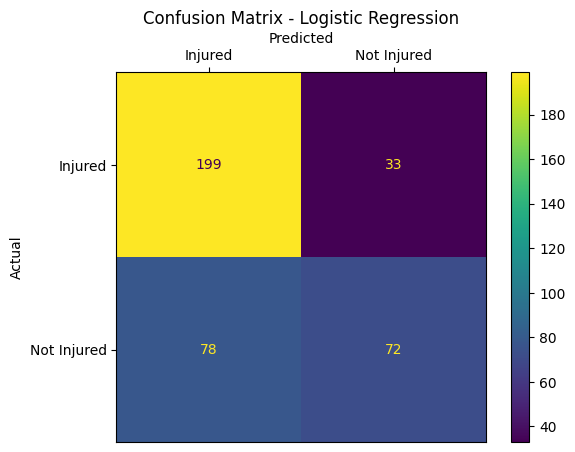

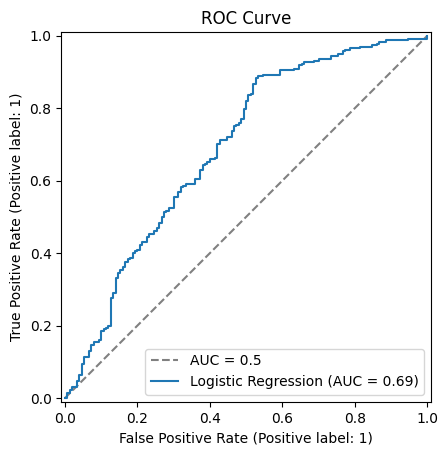

<Figure size 640x480 with 0 Axes>

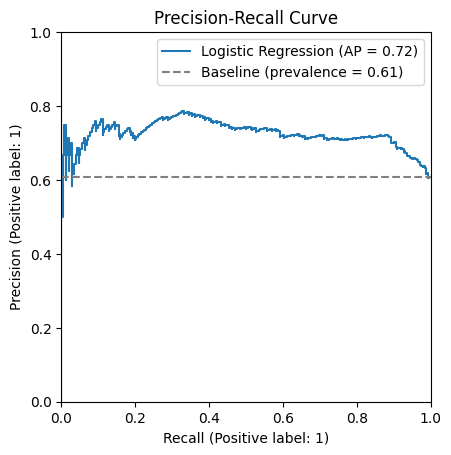

<Figure size 640x480 with 0 Axes>

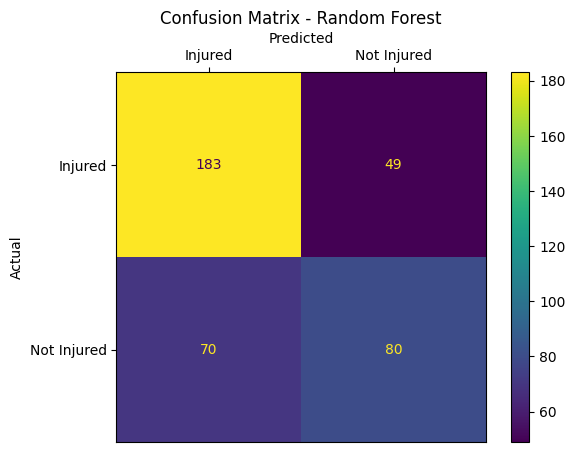

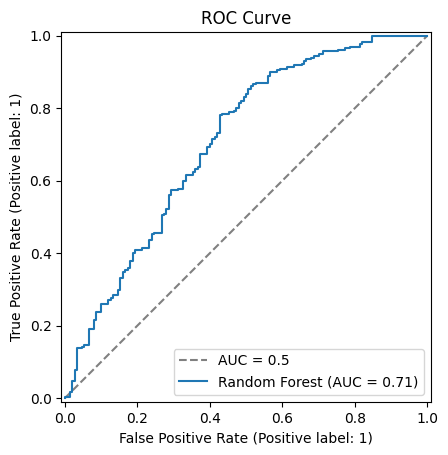

<Figure size 640x480 with 0 Axes>

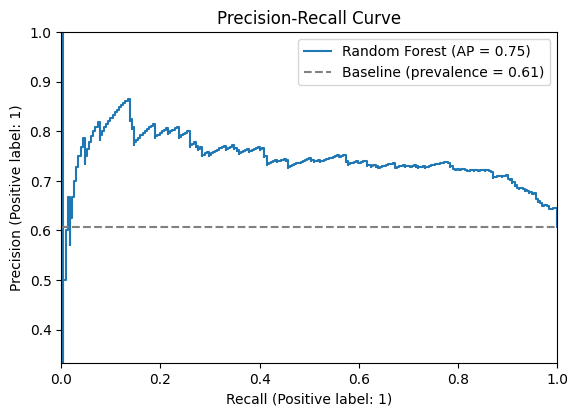

<Figure size 640x480 with 0 Axes>

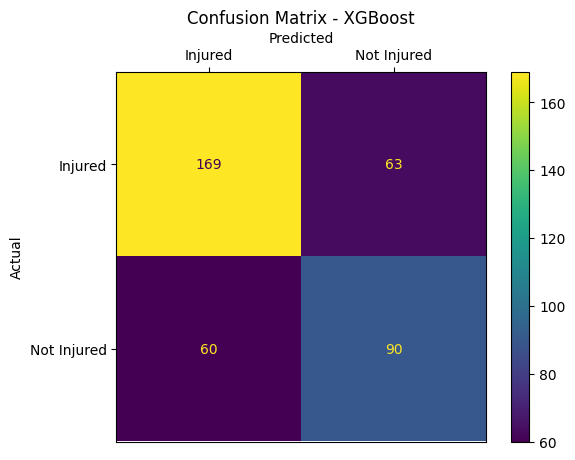

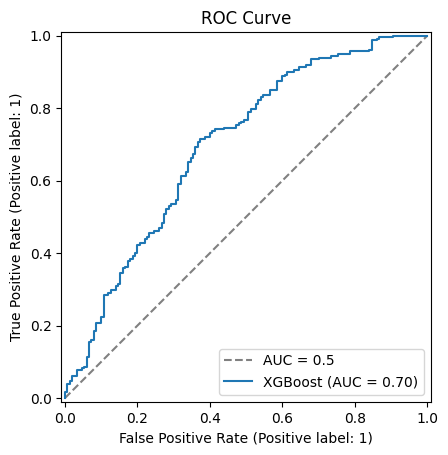

<Figure size 640x480 with 0 Axes>

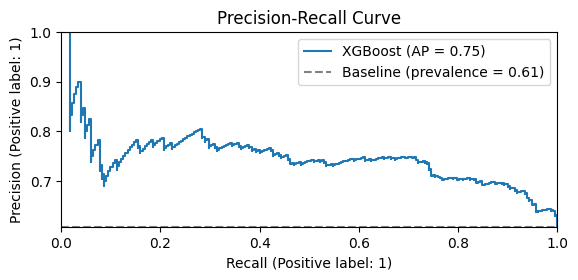

<Figure size 640x480 with 0 Axes>

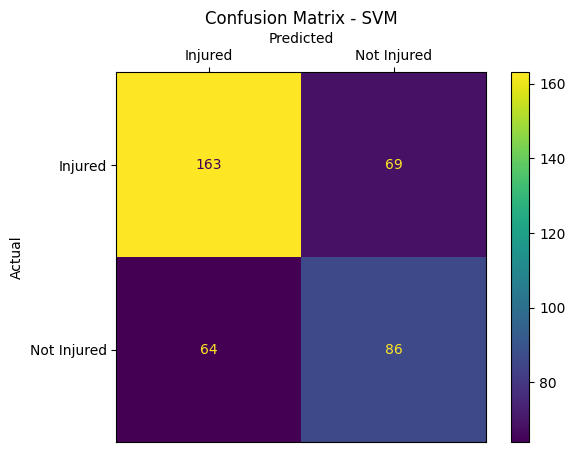

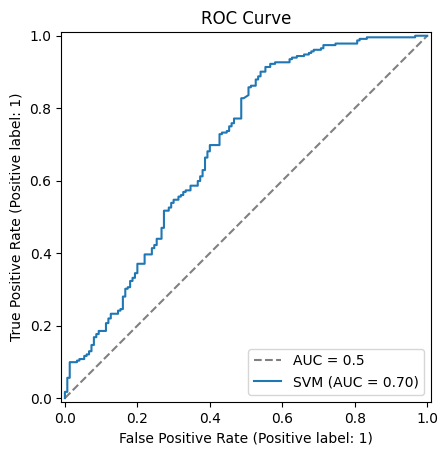

<Figure size 640x480 with 0 Axes>

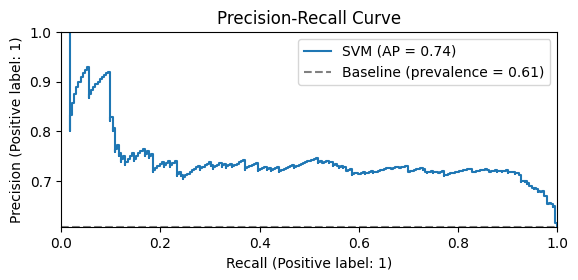

In [22]:
from core.evaluation import SklearnAPIPredictor, model_test_summary


print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print()

for model_name, model in trained_models.items():
    print('\n' + '='*50)
    print(f"Model: {model_name}")
    best_threshold = results[model_name]['best_threshold']
    pred = SklearnAPIPredictor(model)
    test_summary = model_test_summary(model, X_test, y_test,
        threshold=best_threshold,
        predictor=pred,
        model_name=model_name,
        save_predictions=True,
    )
    
    results[model_name].update(test_summary)

Model Performance Comparison by Test ROC AUC:
                 Model  Test ROC AUC  Test PR AUC  Test Accuracy  \
1        Random Forest        0.7065       0.7458         0.6885   
2              XGBoost        0.6964       0.7456         0.6780   
3                  SVM        0.6956       0.7433         0.6518   
0  Logistic Regression        0.6894       0.7245         0.7094   

   Test Precision  Test Recall  Test F1-Score  Test Prevalence  Test Threshold  
1          0.7233       0.7888         0.6641           0.6073          0.5936  
2          0.7380       0.7284         0.6636           0.6073          0.6325  
3          0.7181       0.7026         0.6371           0.6073          0.6055  
0          0.7184       0.8578         0.6733           0.6073          0.4619  

Best performing model: Random Forest
Best Test ROC AUC Score: 0.7065


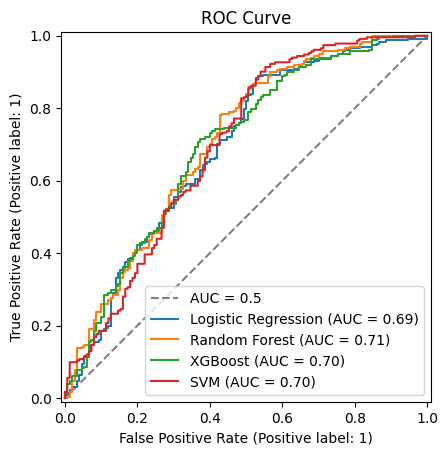

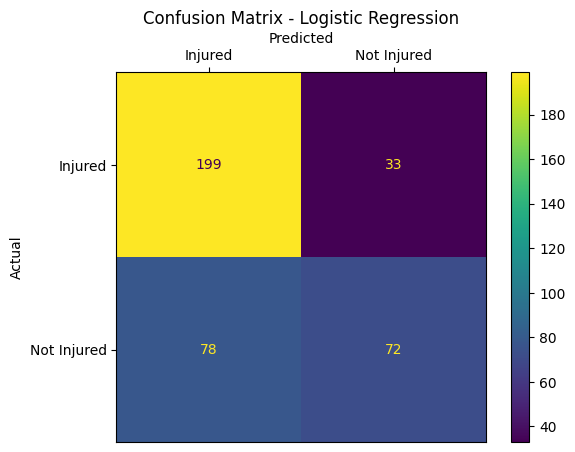

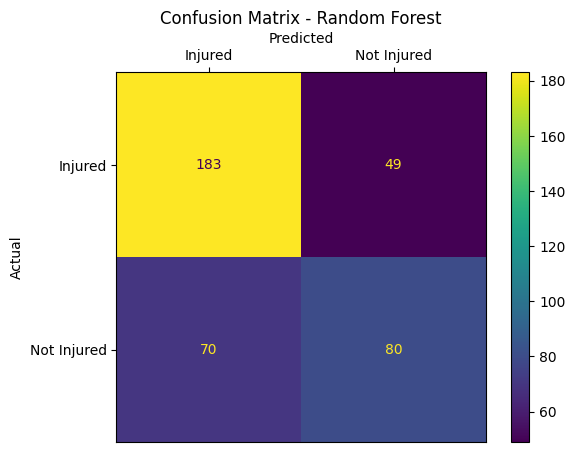

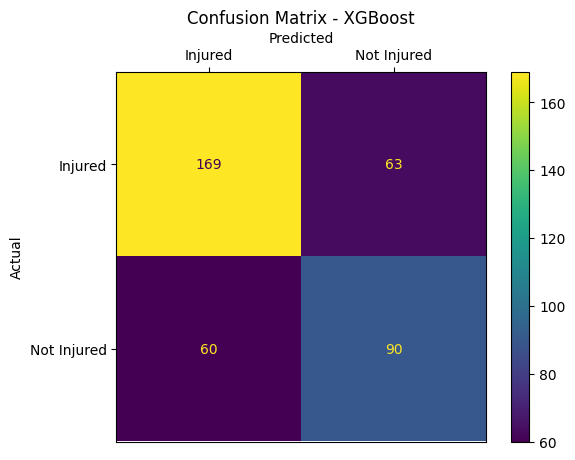

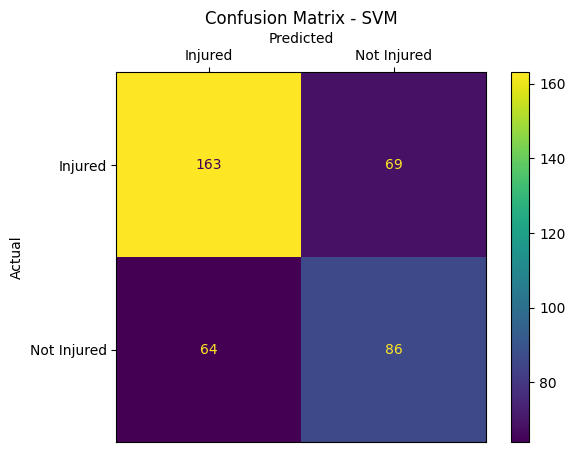

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay


comparison_data = []
ax = plt.gca()

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='AUC = 0.5')

for model_name, result in results.items():
    comparison_data.append({
        'Model': model_name,
        'Test ROC AUC': result['auc_roc'],
        'Test PR AUC': result['auc_pr'],
        'Test Accuracy': result['accuracy'],
        'Test Precision': result['precision'],
        'Test Recall': result['recall'],
        'Test F1-Score': result['f1'],
        'Test Prevalence': result['prevalence'],
        'Test Threshold': result['threshold'],
    })
    roc_disp = RocCurveDisplay.from_predictions(
        y_test, 
        result['y_pred_proba'], 
        name=model_name,
        ax=ax,
    )
roc_disp.ax_.set_title('ROC Curve')

for model_name, result in results.items():
    class_labels = ['Injured', 'Not Injured']
    cm_disp = ConfusionMatrixDisplay.from_predictions(
        y_test, 
        result['y_pred'], 
        display_labels=class_labels,
        labels=[1, 0]
    )
    cm_disp.ax_.xaxis.set_label_position('top')
    cm_disp.ax_.xaxis.set_ticks_position('top')
    cm_disp.ax_.xaxis.set_label_text('Predicted')
    cm_disp.ax_.yaxis.set_label_text('Actual')
    cm_disp.ax_.set_title(f'Confusion Matrix - {model_name}')

PRIMARY_METRIC = 'Test ROC AUC'
comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values(PRIMARY_METRIC, ascending=False)

print(f"Model Performance Comparison by {PRIMARY_METRIC}:")
print('='*50)
print(comparison_df.round(4))

best_model_name = comparison_df.iloc[0]['Model']
print(f"\nBest performing model: {best_model_name}")
print(f"Best {PRIMARY_METRIC} Score: {comparison_df.iloc[0][PRIMARY_METRIC]:.4f}")

In [ ]:
import pickle
from pathlib import Path

if SAVE_MODEL:
    folder_path = Path(f"{c.RICKD_MODELS_FOLDER}/{MODEL_NAME}")
    folder_path.mkdir(parents=True, exist_ok=True)

    with open(f"{folder_path}/results.pkl", "wb") as f:
        pickle.dump(results, f)
